In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns

# Read, format and save raw data from ROIs #

In [31]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn')

In [17]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'

investigator = 'Sofia'

In [32]:
dateloc = str(path).rfind("202")
date = str(path)[dateloc : dateloc+10]

folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if (str(i)[-7:] == 'results') == True]

ch = []
conc_tub = []
conc_DCX = []
DCX_type = []

for i in folders:
    CHloc = str(i).find("CH")
    tubloc = str(i).rfind(tub)
    DCXloc = str(i).rfind(DCX)
    dcxtype = str(i).find("type")
    ch = ch + [str(i)[CHloc+2:CHloc+4]]
    conc_tub = conc_tub + [(str(i)[tubloc+3:tubloc+5])]
    conc_DCX = conc_DCX + [(str(i)[DCXloc+3:DCXloc+6])]
    DCX_type = DCX_type + [(str(i)[dcxtype+4:DCXloc-1])]

date,ch, conc_tub, conc_DCX, DCX_type

('2022-08-12',
 ['11', '12', '13', '21', '22'],
 ['06', '06', '06', '06', '06'],
 ['050', '035', '100', '025', '014'],
 ['R102S', 'R102S', 'R102S', 'R102S', 'R102S'])

In [33]:
tub_conc =  [float(i) for i in conc_tub]
DCX_conc =  [float(i) for i in conc_DCX]
frame_analyzer = pd.read_csv(path/'frame_rates_avg.csv',sep=',')
pixel =  0.107 #0.107 #0.0633
folders

[WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn/CH11_tub06uM_typeR102S_DCX050nM-results'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn/CH12_tub06uM_typeR102S_DCX035nM-results'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn/CH13_tub06uM_typeR102S_DCX100nM-results'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn/CH21_tub06uM_typeR102S_DCX025nM-results'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-08-12_DCX-R102S_dyn/CH22_tub06uM_typeR102S_DCX014nM-results')]

In [34]:
#frame_analyzer = frame_analyzer.iloc[[1,3]].reset_index()
frame_analyzer

,Directory,Mean,SD,Frames,Outliers,MeanWOutliers,SDWOutliers
0,D:\Sofia\2022_2summer-fall\2022-08-12_DCX-R102...,5.04,0.02,400,1,10.32,105.44
1,D:\Sofia\2022_2summer-fall\2022-08-12_DCX-R102...,5.04,0.02,400,1,10.24,103.95
2,D:\Sofia\2022_2summer-fall\2022-08-12_DCX-R102...,5.04,0.02,400,1,10.13,101.77
3,D:\Sofia\2022_2summer-fall\2022-08-12_DCX-R102...,5.04,0.02,400,1,10.22,103.58
4,D:\Sofia\2022_2summer-fall\2022-08-12_DCX-R102...,5.04,0.02,400,1,10.26,104.27


In [21]:
def open_roi_poly(k,name):
    roi_path = folders[k]/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','x3','y1','y2','y3'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x'][0],'x2': roi_data[key]['x'][1],'x3': roi_data[key]['x'][2],'y1': roi_data[key]['y'][0],'y2': roi_data[key]['y'][1],'y3': roi_data[key]['y'][2]}, ignore_index=True)
    return roi_df

def open_roi_line(k,name):
    roi_path = folders[k]/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [22]:
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'
poly_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate)
line_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate)

In [23]:
def poly_dynamics(k):
        
    data = open_roi_poly(k,'kymoslopes.zip')
    supp = open_roi_line(k,'start.zip')
    
    spf = frame_analyzer['Mean'][k];
    frames = frame_analyzer['Frames'][k]-2
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;
    
    n = len(data)
    pre_df = {'Date': np.full((n), date), 'Investigator': np.full((n), investigator),
              'CH': np.full((n), ch[k]),tubulin: np.full((n), tub_conc[k]),DCXconc: np.full((n), DCX_conc[k])}
    df = pd.DataFrame(pre_df) 
    
    df[Length] = abs((data['x2']-data['x1'])*pixel)
    
    data[Lifetime] = abs((data['y2']-data['y1'])*spf/60)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames-2 else np.NaN, axis=1)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x[Lifetime] != 0 else np.NaN, axis=1)
    
    df[GrowthRate] = df[Length]/df[Lifetime]
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NAN )
    
    df[TimeToNucleate] = (data['y1']-start)*spf/60
    
    df[ShrinkageLength] = abs((data['x3']-data['x2'])*pixel)
    df[ShrinkageLifetime] = abs((data['y3']-data['y2'])*spf/60)
    df[ShrinkageLifetime] = df[ShrinkageLifetime].apply(lambda x: np.NAN if x == 0 else x)
    df[ShrinkageRate] = df[ShrinkageLength]/df[ShrinkageLifetime]
    
    df.loc[pd.isnull(df[GrowthRate]), 
           [Length,Lifetime,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate]] = np.NaN
    
    df['Rescues'] = df[[Length,ShrinkageLength]].apply(lambda x: True if abs(x[Length]-x[ShrinkageLength]) > pixel*5 else False, axis=1)
    
    df['DCX Type'] = DCX_type[k]
        
    return df

def line_dynamics(k):
        
    data = open_roi_line(k,'kymoslopes.zip')
    #data_even = data.iloc[::2].reset_index()
    #data_odd = data.iloc[1::2].reset_index()
    data_even = data
    data_odd = data
    
    supp = open_roi_line(k,'start.zip')
    
    spf = frame_analyzer['Mean'][k];
    frames = frame_analyzer['Frames'][k]-2
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;
    
    n = len(data_even)
    pre_df = {'Date': np.full((n), date),'CH': np.full((n), ch[k]),'Concentration ' r'$(\mu M)$': np.full((n), conc[k])}
    df = pd.DataFrame(pre_df) 
    
    data_even[Length] = abs((data_even['x2']-data_even['x1'])*pixel)
    data_even[Lifetime] = abs((data_even['y2']-data_even['y1'])*spf/60)
    df[GrowthRate] = data_even[Length]/data_even[Lifetime]
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NaN )
    
    data[Lifetime] = abs((data_odd['y2']-data_odd['y1'])*spf/60)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames else np.NaN, axis=1)
    
    df[Length] = df[GrowthRate]*df[Lifetime]
    
    df[TimeToNucleate] = ((data_odd[['y1','y2']].min(axis=1))-start)*spf/60
    
    df.loc[pd.isnull(df[GrowthRate]), [Length,Lifetime,TimeToNucleate]] = np.NaN
    
    df = df[['Date','CH','Concentration ' r'$(\mu M)$',Length,Lifetime,GrowthRate,TimeToNucleate]]
        
    return df

In [24]:
path.parents[1]

WindowsPath('D:/Sofia')

In [25]:
newdirectory = str(path.parents[1])+'//Data_Sheets_summer'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/Data_Sheets_summer')

In [35]:
df = poly_dynamics(0)
for i in range(1,len(ch)):
    df0 = poly_dynamics(i)
    df = df.append(df0, ignore_index=True)

df.to_csv(path/(investigator+'_'+date +'.csv'), encoding='utf-8', index=False)
df.to_csv(newmydir/(investigator+'_'+date+'.csv'), encoding='utf-8', index=False)
df

,Date,Investigator,CH,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues,DCX Type
0,2022-08-12,Sofia,11,6.0,50.0,0.838167,2.380,0.352171,0.287,0.927333,0.056,16.559582,False,R102S
1,2022-08-12,Sofia,11,6.0,50.0,2.175667,6.580,0.330648,0.791,2.247000,0.168,13.374999,False,R102S
2,2022-08-12,Sofia,11,6.0,50.0,1.819000,4.256,0.427397,0.343,1.854667,0.196,9.462574,False,R102S
3,2022-08-12,Sofia,11,6.0,50.0,0.454750,1.176,0.386692,3.591,0.561750,0.021,26.750000,False,R102S
4,2022-08-12,Sofia,11,6.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,R102S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,2022-08-12,Sofia,22,6.0,14.0,0.856000,2.730,0.313553,2.674,0.856000,0.084,10.190476,False,R102S
216,2022-08-12,Sofia,22,6.0,14.0,0.668750,1.701,0.393151,9.142,0.642000,0.021,30.571429,False,R102S
217,2022-08-12,Sofia,22,6.0,14.0,0.749000,1.680,0.445833,0.679,0.829250,0.084,9.872024,False,R102S
218,2022-08-12,Sofia,22,6.0,14.0,0.722250,1.659,0.435353,13.867,0.909500,0.042,21.654762,False,R102S


In [27]:
dfmean = df.groupby('CH').mean()
#dfmean.to_csv(path/(date+'_0_mean.csv'), encoding='utf-8', index=False)
dfmean

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
11,6.0,0.0,1.959173,4.812964,0.457056,13.442257,2.032419,0.129710,18.520381,0.00000
12,6.0,35.0,0.745328,2.127176,0.376794,6.118824,0.826103,0.103353,9.245999,0.00000
13,6.0,14.0,2.271780,4.765781,0.496812,3.063125,2.379003,0.119736,22.346066,0.00000
21,6.0,100.0,2.153725,4.820291,0.479358,4.051556,2.226057,0.174293,13.778312,0.00000
22,6.0,50.0,3.777164,5.013301,0.760084,3.109678,3.861507,0.180083,23.528675,0.00000
23,6.0,25.0,2.409553,4.471557,0.576739,5.136144,2.411893,0.124704,21.167492,0.02381


In [68]:
dfstd = df.groupby('CH').std()
#dfstd.to_csv(path/(date+'_0_std.csv'), encoding='utf-8', index=False)
dfstd

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
11,0.0,0.0,2.220003,5.607553,0.065197,2.292193,1.395496,0.921506,0.641015,0.262082
12,0.0,0.0,2.141587,4.409483,0.054800,3.401007,2.164654,0.683917,1.171587,0.308520
13,0.0,0.0,3.114664,5.224431,0.101222,2.719833,1.212097,0.659128,1.351292,0.408032
22,0.0,0.0,2.888860,6.023168,0.068091,0.961065,1.543716,0.755316,0.779552,0.000000


# Preliminary plot Histograms #

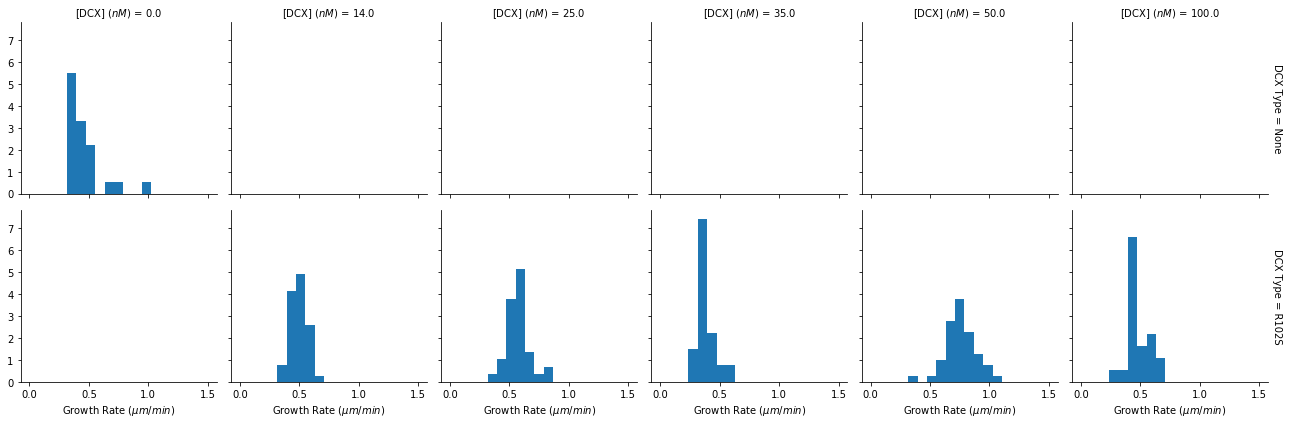

In [30]:
g = sns.FacetGrid(df, col=DCXconc, row='DCX Type', margin_titles=True)
bins = np.linspace(0, 1.5, 20)
g.map(plt.hist, GrowthRate, bins=bins, density=True)

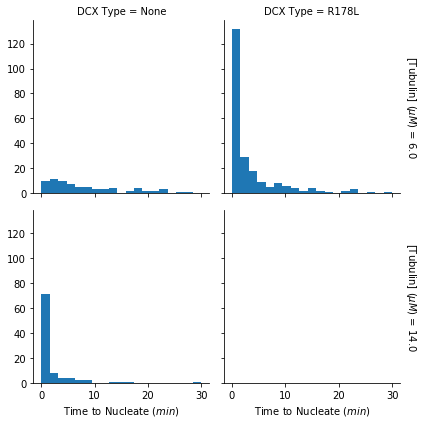

In [58]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 30, 20)
g.map(plt.hist, TimeToNucleate, bins=bins)

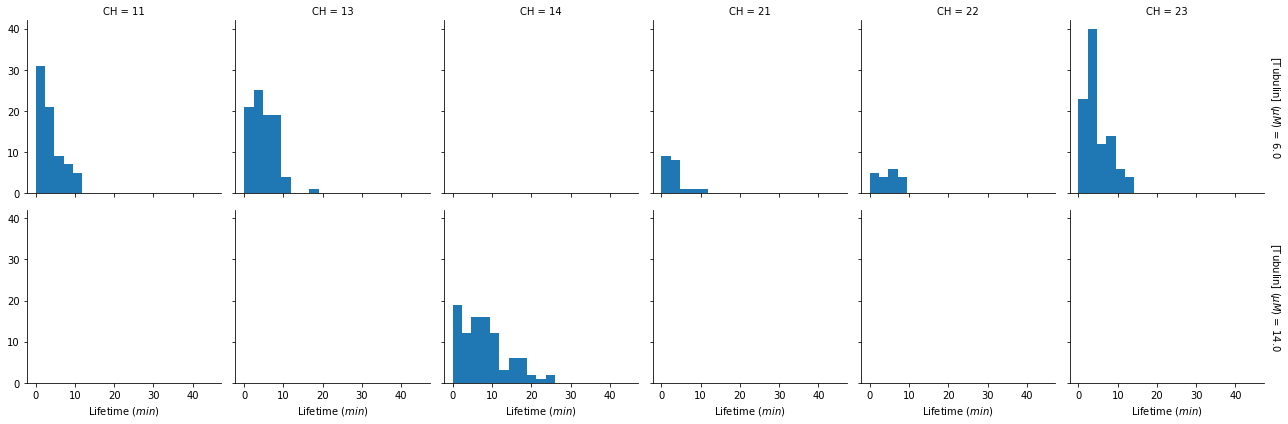

In [59]:
g = sns.FacetGrid(df, row=tubulin, col="CH", margin_titles=True)
bins = np.linspace(0, 45, 20)
g.map(plt.hist, Lifetime, bins=bins)

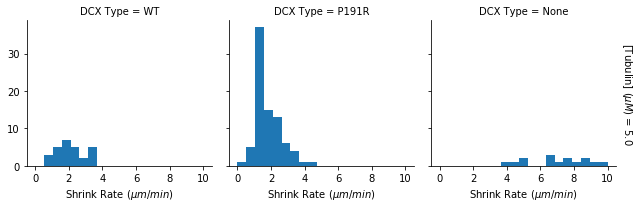

In [53]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 10, 20)
g.map(plt.hist, ShrinkageRate, bins=bins)